In [1]:
import sys

sys.path.append('.')
from piece_v2 import piece_v2

piece_v2.start(should_send_to_score=False)

0.4512360135404494
0.09812400810854885
0.7949329158287792
0.9020671128341227
0.17079854801046349
0.13265478691822136
0.1296342305321405
0.1465910412085263
0.3323201717859877
0.5821619476192703
0.10054544536509012
0.833686738600081
0.23426369940477246
0.13581113556081092
0.425624388713274
0.7720661426475637
0.7663679683803634
0.22497835924587295
0.9636537100909186
0.1466904833366285
0.2939529040144091
0.5311036810328791
0.11752784466506369


----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 57120)
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/socketserver.py", line 318, in _handle_request_noblock
    self.process_request(request, client_address)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/socketserver.py", line 349, in process_request
    self.finish_request(request, client_address)
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/socketserver.py", line 362, in finish_request
    self.RequestHandlerClass(request, client_address, self)
    ~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/danielstahl/Documents/Projects/py-soundmining-scratchp

In [2]:
from soundmining_tools import note, spectrum
import math

fundamental = note.note_to_hertz("C0")
first_partial = note.note_to_hertz("C1")
fact = spectrum.make_fact(fundamental, first_partial)
basic_spectrum = spectrum.make_spectrum(fundamental, fact, 50)

#fact = spectrum.make_fact(basic_spectrum[5], basic_spectrum[13])
# 2 3. Good with c major maj chord
fact = spectrum.make_fact(basic_spectrum[2], basic_spectrum[3])
print(fact)
spectrum_carrier = basic_spectrum[5]
spectrum_modulator = fact * spectrum_carrier

fm_spectrum = spectrum.make_fm_synthesis(spectrum_carrier, spectrum_modulator, 100)

rythm_carrier = 1
rythm_modulator = rythm_carrier * fact
rythm_spectrum = spectrum.make_fm_synthesis(rythm_carrier, rythm_modulator, 100)

time_spectrum = [(1 / p[0], 1 / p[1]) for p in rythm_spectrum]
time_spectrum


0.3333333333333335


[(1.0, 1.0),
 (0.7499999999999999, 1.5000000000000004),
 (0.5999999999999999, 3.0000000000000027),
 (0.4999999999999999, 2251799813685248.0),
 (0.42857142857142844, 2.9999999999999947),
 (0.3749999999999999, 1.4999999999999984),
 (0.33333333333333326, 0.9999999999999991),
 (0.29999999999999993, 0.7499999999999994),
 (0.27272727272727265, 0.5999999999999995),
 (0.2499999999999999, 0.49999999999999967),
 (0.2307692307692307, 0.4285714285714283),
 (0.21428571428571422, 0.3749999999999998),
 (0.19999999999999993, 0.33333333333333315),
 (0.18749999999999992, 0.29999999999999977),
 (0.17647058823529405, 0.2727272727272726),
 (0.16666666666666663, 0.2499999999999999),
 (0.1578947368421052, 0.23076923076923064),
 (0.14999999999999994, 0.21428571428571416),
 (0.1428571428571428, 0.1999999999999999),
 (0.13636363636363633, 0.18749999999999992),
 (0.1304347826086956, 0.17647058823529402),
 (0.12499999999999994, 0.16666666666666657),
 (0.11999999999999997, 0.15789473684210517),
 (0.115384615384615

Times based on time spectrum. Then make rythms based by multiplying the time. E.g if the time is 0.5. Then you can make a rythm 2, 3, 5 = 1.0, 1.5, 2.5. 

Make envelops with times also. 

Use sine as curve in env. 

Then you can make themes both with pitch, rythm and the shape of the env. 

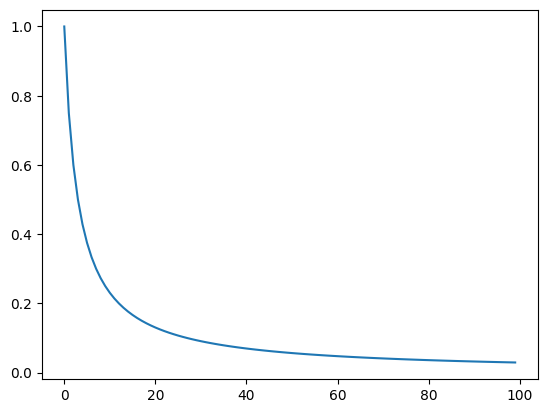

In [3]:
import matplotlib.pyplot as plt

x = range(100)
plt.plot(x, [t[0] for t in time_spectrum])
plt.show()

In [47]:
from soundmining_tools.modular.instrument import AddAction, AudioInstrument
from soundmining_tools.generative import *
from soundmining_tools.supercollider_receiver import ExtendedNoteHandler, PatchArguments
from soundmining_tools.supercollider_client import SupercolliderClient
from enum import StrEnum

static_control = piece_v2.instruments.static_control
line_control = piece_v2.instruments.line_control
signal_sum = piece_v2.instruments.signal_sum
two_block_sine_control = piece_v2.instruments.two_block_sine_control
two_block_exp_control = piece_v2.instruments.two_block_exp_control
three_block_sine_control = piece_v2.instruments.three_block_sine_control
three_block_exp_control = piece_v2.instruments.three_block_exp_control
four_block_sine_control = piece_v2.instruments.four_block_sine_control
four_block_exp_control = piece_v2.instruments.four_block_exp_control


Dynamic = StrEnum('Dynamic', ['P', 'MF', 'F'])

def make_amp(dynamic: Dynamic) -> float:
    match dynamic:
        case Dynamic.P:
            return random_range(0.09, 0.15)
        case Dynamic.MF:
            return random_range(0.15, 0.50)
        case Dynamic.F:
            return random_range(0.5, 1)        

def low_modindex(amp: float) -> float:
    return 10 + (random_range(5, 20) * amp)

def high_modindex(amp: float) -> float:
    return 100 + (random_range(500, 2000) * amp)

NEARLY_ZERO = 0.0000001

def make_two_block_sine_control(times: tuple[int, int], time_tick: float, levels: Dynamic) -> tuple[float, AudioInstrument]:
    absolute_levels = (0, make_amp(levels), 0)
    absolute_times = (times[0] * time_tick, times[1] * time_tick)
    duration = sum(absolute_times)
    return (duration, two_block_sine_control(levels=absolute_levels, times=absolute_times))

def make_two_block_exp_control(times: tuple[int, int], time_tick: float, levels: Dynamic) -> tuple[float, AudioInstrument]:
    absolute_levels = (NEARLY_ZERO, make_amp(levels), NEARLY_ZERO)
    absolute_times = (times[0] * time_tick, times[1] * time_tick)
    duration = sum(absolute_times)
    return (duration, two_block_exp_control(levels=absolute_levels, times=absolute_times))

def make_three_block_sine_control(times: tuple[int, int, int], time_tick: float, levels: tuple[Dynamic, Dynamic]) -> tuple[float, AudioInstrument]:
    absolute_levels = (0, make_amp(levels[0]), make_amp(levels[1]), 0)
    absolute_times = (times[0] * time_tick, times[1] * time_tick, times[2] * time_tick)
    duration = sum(absolute_times)
    return (duration, three_block_sine_control(levels=absolute_levels, times=absolute_times))

def make_three_block_exp_control(times: tuple[int, int, int], time_tick: float, levels: tuple[Dynamic, Dynamic]) -> tuple[float, AudioInstrument]:
    absolute_levels = (NEARLY_ZERO, make_amp(levels[0]), make_amp(levels[1]), NEARLY_ZERO)
    absolute_times = (times[0] * time_tick, times[1] * time_tick, times[2] * time_tick)
    duration = sum(absolute_times) 
    return (duration, three_block_exp_control(levels=absolute_levels, times=absolute_times))

def make_four_block_sine_control(times: tuple[int, int, int, int], time_tick: float, levels: tuple[Dynamic, Dynamic, Dynamic]) -> tuple[float, AudioInstrument]:
    absolute_levels = (0, make_amp(levels[0]), make_amp(levels[1]), make_amp(levels[2]), 0)
    absolute_times = (times[0] * time_tick, times[1] * time_tick, times[2] * time_tick, times[3] * time_tick)
    duration = sum(absolute_times)
    return (duration, four_block_sine_control(levels=absolute_levels, times=absolute_times))

def make_four_block_exp_control(times: tuple[int, int, int, int], time_tick: float, levels: tuple[Dynamic, Dynamic, Dynamic]) -> tuple[float, AudioInstrument]:
    absolute_levels = (NEARLY_ZERO, make_amp(levels[0]), make_amp(levels[1]), make_amp(levels[2]), NEARLY_ZERO)
    absolute_times = (times[0] * time_tick, times[1] * time_tick, times[2] * time_tick, times[3] * time_tick)
    duration = sum(absolute_times)
    return (duration, four_block_exp_control(levels=absolute_levels, times=absolute_times))
    

def play_fm1(start: float, duration: float, pitch: float, mod_ratio1: float, amp: float, pan_control: AudioInstrument):
    mod_freq = static_control(pitch * mod_ratio1) 
    mod_peak = random_range(0.15, 0.85)      
    mod_amp = two_block_sine_control([low_modindex(amp), low_modindex(amp), low_modindex(amp)], [1 - mod_peak, mod_peak])
    #mod_amp = two_block_exp_control([low_modindex(amp), low_modindex(amp), low_modindex(amp)], [1 - mod_peak, mod_peak])
    mod = (
        piece_v2.synth_player.note()
        #.saw(freq=mod_freq, amp=mod_amp)
        .sine(freq=mod_freq, amp=mod_amp)
        .audio_stack.pop()
    )        
    car_freq = static_control(pitch)
    peak = random_range(0.15, 0.85)
    car_amp = two_block_sine_control([0, amp, 0], [1 - peak, peak])
    #car_amp = two_block_exp_control([0.00001, amp, 0.00001], [1 - peak, peak])
    fm_mod = signal_sum(car_freq, mod).add_action(AddAction.TAIL_ACTION)
    (
        piece_v2.synth_player.note()
            #.triangle(freq=fm_mod, amp=car_amp)
            .sine(freq=fm_mod, amp=car_amp)
            .pan(pan_control)
            .play(start, duration, output_bus=0)
    )

def play_fm2(start: float, duration: float, car_amp: AudioInstrument, mod_amp: AudioInstrument, pitch: float, mod_ratio1: float, pan_control: AudioInstrument):    
    mod_freq = static_control(pitch * mod_ratio1)     
    
    mod = (
        piece_v2.synth_player.note()        
        .sine(freq=mod_freq, amp=mod_amp)
        .audio_stack.pop()
    )        
    car_freq = static_control(pitch)
    fm_mod = signal_sum(car_freq, mod).add_action(AddAction.TAIL_ACTION)
    (
        piece_v2.synth_player.note()            
            .sine(freq=fm_mod, amp=car_amp)
            .pan(pan_control)
            .play(start, duration, output_bus=0)
    )
    

In [57]:
piece_v2.reset()
piece_v2.synth_player.start()

class MyHandler(ExtendedNoteHandler):
    def __init__(self, client: SupercolliderClient):
        super().__init__(client)

    def handle_note1(self, patch_arguments: PatchArguments):
        match patch_arguments.octave:
            case 2:
                amp = random_range(0.09, 0.15)
            case 3:
                amp = random_range(0.15, 0.50)
            case 4:
                amp = random_range(0.5, 1)
        print(amp)
        pitch = fm_spectrum[patch_arguments.note][0]   
        pan = random_range(-1, 1)     
        #duration = random_range(8, 13)
        duration = random_range(3, 5)
        #duration = random_range(0.5, 0.9)
        #play_fm1(patch_arguments.start, duration, pitch, fact, patch_arguments.amp, static_control(pan))

        play_fm1(patch_arguments.start, duration, pitch, fact, amp, static_control(pan))

    def handle_note2(self, patch_arguments: PatchArguments):
        match patch_arguments.octave:
            case 2:
                time_tick = time_spectrum[0][0]
                times = (3, 2, 5)
                levels = (Dynamic.MF, Dynamic.P)
            case 3:
                time_tick = time_spectrum[2][0]
                times = (5, 2, 3)
                levels = (Dynamic.P, Dynamic.MF)
            case 4:
                time_tick = time_spectrum[4][0]
                times = (3, 2, 5)                
                levels = (Dynamic.MF, Dynamic.P)

        pitch = fm_spectrum[patch_arguments.note][0]   
        pan = random_range(-1, 1)             
        duration, car_amp = make_three_block_sine_control(times=times, time_tick=time_tick, levels=levels)                
        mod_amp = static_control(low_modindex(make_amp(Dynamic.MF)))
        play_fm2(patch_arguments.start, duration, car_amp, mod_amp, pitch, fact, static_control(pan))


    def handle_note3(self, patch_arguments: PatchArguments):
        match patch_arguments.octave:
            case 2:
                time_tick = time_spectrum[0][0]
                times = (2, 3, 5)                
                levels = (Dynamic.P, Dynamic.F)
            case 3:
                time_tick = time_spectrum[2][0]
                times = (2, 3, 5)
                levels = (Dynamic.P, Dynamic.F)
            case 4:
                time_tick = time_spectrum[4][0]
                times = (2, 3, 5)                
                levels = (Dynamic.P, Dynamic.F)

        pitch = fm_spectrum[patch_arguments.note][0]   
        pan = random_range(-1, 1)             
        duration, car_amp = make_three_block_exp_control(times=times, time_tick=time_tick, levels=levels)                
        mod_amp = static_control(low_modindex(make_amp(Dynamic.P)))                
        play_fm2(patch_arguments.start, duration, car_amp, mod_amp, pitch, fact, static_control(pan))

    def handle_note(self, patch_arguments: PatchArguments):
        self.handle_note3(patch_arguments)

my_handler = MyHandler(piece_v2.supercollider_client)
piece_v2.receiver.set_note_handler(my_handler)

In [77]:
piece_v2.stop()